In [1]:
from mpl_toolkits.axes_grid1 import make_axes_locatable
import pandas as pd
import numpy as np
import matplotlib.pylab as plt
from scdepth import pl, fn, fit
from scipy import stats
import glob
from collections import Counter

In [2]:
from scipy.optimize import brentq

def saturation_from_p_r(p: float, r: float) -> float:
    return 1.0 - (p * (1.0 - p**r)) / (r * (1.0 - p))

def p_for_target_saturation(S_target: float, r: float, eps: float = 1e-10) -> float:
    lo = eps
    hi = 1.0 - eps

    f = lambda p: saturation_from_p_r(p, r) - S_target
    flo, fhi = f(lo), f(hi)
    if flo * fhi > 0:
        return np.nan

    return brentq(f, lo, hi, maxiter=1000)

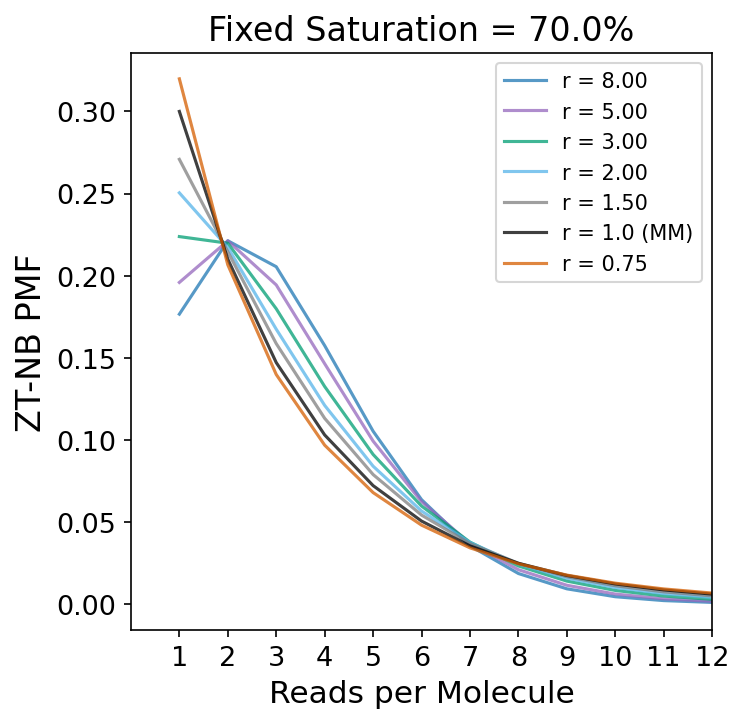

In [3]:
from scipy.stats import nbinom

def predict_pmf(K, rhat : float, phat : float):
    pmf = nbinom.pmf(K, rhat, phat)
    p0  = nbinom.pmf(0, rhat, phat)
    pmf_ztnb = pmf / (1.0 - p0)
    return pmf_ztnb / pmf_ztnb.sum()

fig, rax  = pl.figax(1, 1, s=5)
fig.subplots_adjust(wspace=0.15)

L = 10**8
colors = ['#D55E00', '#000000', '#7F7F7F', '#56B4E9','#009E73','#9467bd', '#1f77b4']
recs = np.arange(5, 90.5, 0.5)
i50 = np.argmin(np.abs(recs - 50.0))
i70 = np.argmin(np.abs(recs - 70.0))

ff = fit.NBLibFit(rhat=1, L=L)
mreads = ff.reads_for_recovery(recs)
msats = ff.predict_saturation(mreads)
K = np.arange(1, 26)
tsat = 0.7
for r, c in zip([0.75, 1,1.5, 2,3,5,8][::-1], colors[::-1]):
    ff = fit.NBLibFit(rhat=r, L=L)
    reads = ff.reads_for_recovery(recs)
    mols = ff.predict_molecules(reads)
    sats = ff.predict_saturation(reads)
    if r == 1:
        lab = f'r = {1.0} (MM)'
    else:
        lab = f'r = {r:.2f}'
    color = (r - 1) / 10
    ls = '-'
    phat = p_for_target_saturation(tsat, r)
    pmf = predict_pmf(K, r, phat)
    rax.plot(K, pmf, color=c, label=lab, alpha=0.75, lw=1.5)

rax.legend(loc = 'upper right')
rax.set_title(f'Fixed Saturation = {tsat*100}%', fontsize=16)

rax.set_xticks(np.arange(1, 13))
rax.set_xlim(0, 12)
rax.set_xlabel('Reads per Molecule', fontsize=15)

rax.set_ylabel('ZT-NB PMF', fontsize=16)
rax.tick_params(axis='both', labelsize=13)


fig.savefig('../figures/Figure 2A ZT-NB.svg', bbox_inches='tight')

0.75 30 26.152912984357123
0.75 50 44.272911120446146
1 30 30.000000000000004
1 50 50.0
1.5 30 35.1576539808349
1.5 50 57.333466114465025
2 30 38.45232578665133
2 50 61.803398874989476
3 30 42.41372525514082
3 50 66.94672712193568
5 30 46.20555918073873
5 50 71.62322562441898
8 30 48.64172015612592
8 50 74.49484755652239


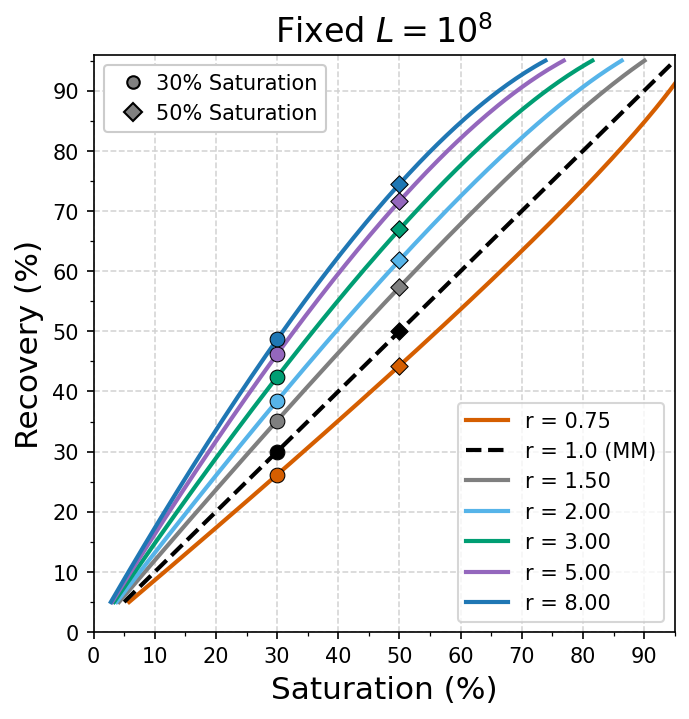

In [4]:
from matplotlib.lines import Line2D


fig, ax = pl.figax(1, 1, s=5)
L = 10**8
colors = ['#D55E00', '#000000', '#7F7F7F', '#56B4E9','#009E73','#9467bd', '#1f77b4']
recs = np.arange(5, 95.5, 0.5)
i50 = np.argmin(np.abs(recs - 50.0))
i70 = np.argmin(np.abs(recs - 70.0))

for r, c in zip([0.75, 1,1.5, 2,3,5,8], colors):
    ff = fit.NBLibFit(rhat=r, L=L)
    reads = ff.reads_for_recovery(recs)
    mols = ff.predict_molecules(reads)
    sats = ff.predict_saturation(reads)
    if r == 1:
        lab = f'r = {1.0} (MM)'
    else:
        lab = f'r = {r:.2f}'
    color = (r - 1) / 10

    #ax.plot(recs, (recs-sats), label=lab, color=c, ls=ls, lw=2.5)
    #ax.scatter(recs[i50], (recs-sats)[i50], s=75, color=c, edgecolor='k', lw=1, zorder=10)
    #ax.scatter(recs[i70], (recs-sats)[i70], s=75, color=c, edgecolor='k', lw=1, zorder=10)    
    ls = '-' if r != 1 else '--'
    #ec ='k' if r != 1 else 'w'
    ax.plot(sats, recs, label=lab, color=c, lw=2, ls=ls)


    for sat, m, sz in zip((30, 50), ('o', 'D'), (50, 35)):
        sr = ff.reads_for_saturation(sat)
        rec = ff.predict_recovery(sr)
        print(r, sat, rec)
        ax.scatter(sat, rec, s=sz, color=c, edgecolor='k', lw=0.5, zorder=10, marker=m)
    #ax.scatter(sats[i70], recs[i70], s=75, color=c, edgecolor='k', lw=1, zorder=10)    

    
ax.set_title(r'Fixed $L = 10^8$', fontsize=16)
#ax.set_xticks(np.arange(10, 91, 10))
#ax.plot([0, 50], [50, 50], ls='--', color='lightgray', zorder=1)
#ax.plot([50, 50], [0, 50], ls='--', color='lightgray', zorder=1)
ax.set_xticks(np.arange(0, 90.5, 10))
ax.set_yticks(np.arange(0, 90.5, 10))
ax.set_xticks(np.arange(5, 95.5, 5), minor=True)
ax.set_yticks(np.arange(5, 95.5, 5), minor=True)
ax.set_xlim(0, 95)
ax.set_ylim(0, 96)

ax.grid(axis='both', color='lightgray', ls='--', lw=0.75)
ax.set_axisbelow(True)


#ax.set_ylabel('Difference Between\nRecovery and Saturation (pp)', fontsize=14)
ax.set_ylabel('Recovery (%)', fontsize=15)
ax.set_xlabel('Saturation (%)', fontsize=15)

sat_handles = [
    Line2D([0], [0], marker='o', color='none',
           markerfacecolor='gray', markeredgecolor='black',
           markersize=6, linestyle='None', label='30% Saturation'),
    Line2D([0], [0], marker='D', color='none',
           markerfacecolor='gray', markeredgecolor='black',
           markersize=6, linestyle='None', label='50% Saturation'),
]

lgd1 = ax.legend(handles=sat_handles,loc='upper left', frameon=True, framealpha=1, handletextpad=0.1, fontsize=10)

ax.legend(loc = 'lower right')
ax.add_artist(lgd1)
fig.savefig('../Figures/Figure 2B Rec vs Sat.svg', bbox_inches='tight')

In [5]:
cdf = pd.read_csv('../data/cohort.csv')
adf = pd.read_csv('../data/cohort_annotations.csv')

dfs = []
for i, r in cdf.iterrows():
    ch = r.dataset
    bdf = pd.read_csv(f'../{ch}/{r["sample"]}/scdepth_fit_baseline.txt', sep='\t')
    dfs.append(bdf)
df = pd.concat(dfs)
cdf = cdf.merge(df, left_on='sample', right_on='sample', how='left')
cdf = cdf.merge(adf, left_on=['group','subgroup'], right_on=['group','subgroup'], how='left')

visium_hd FFPE 2.092741061960721 7.1697217536599736
visium_hd Fixed_Frozen 1.6790409736814509 2.5806943668633378
visium_hd Fresh_Frozen 1.349894172306459 3.5828824892652245
visium FFPE 1.993496728460092 4.139556612696821
PBMC_scrna 10X_3p_v3 2.414615062154787 3.191462057437893
PBMC_scrna 10X_3p_v31 1.3498966301737372 2.7259835071076948
PBMC_scrna 10X_3p_v4 1.3654544278872562 1.691762930239559
PBMC_scrna 10X_5p_v2 3.6904386673435066 3.6904386673435066
PBMC_scrna 10X_5p_v3 3.682247103042966 3.682247103042966
PBMC_scrna_flex 10X_flex_v1 2.190349909838281 4.244888394858376
Melanoma 10X_3p_v31 1.52333192943182 3.7250566385805066
Brain 10X_3p_v3 0.9240857508787408 3.723565224791858
Colon 10X_5p_v2 1.7739872661457492 3.1527264783281104
Heart 10X_3p_v3 1.3053933460552145 2.0375126195348723
OvaryCA_CD45m 10X_3p_v3 0.7889005596917716 1.816397773116715
OvaryCA_CD45p 10X_3p_v3 0.5922081134657512 2.703568618600183


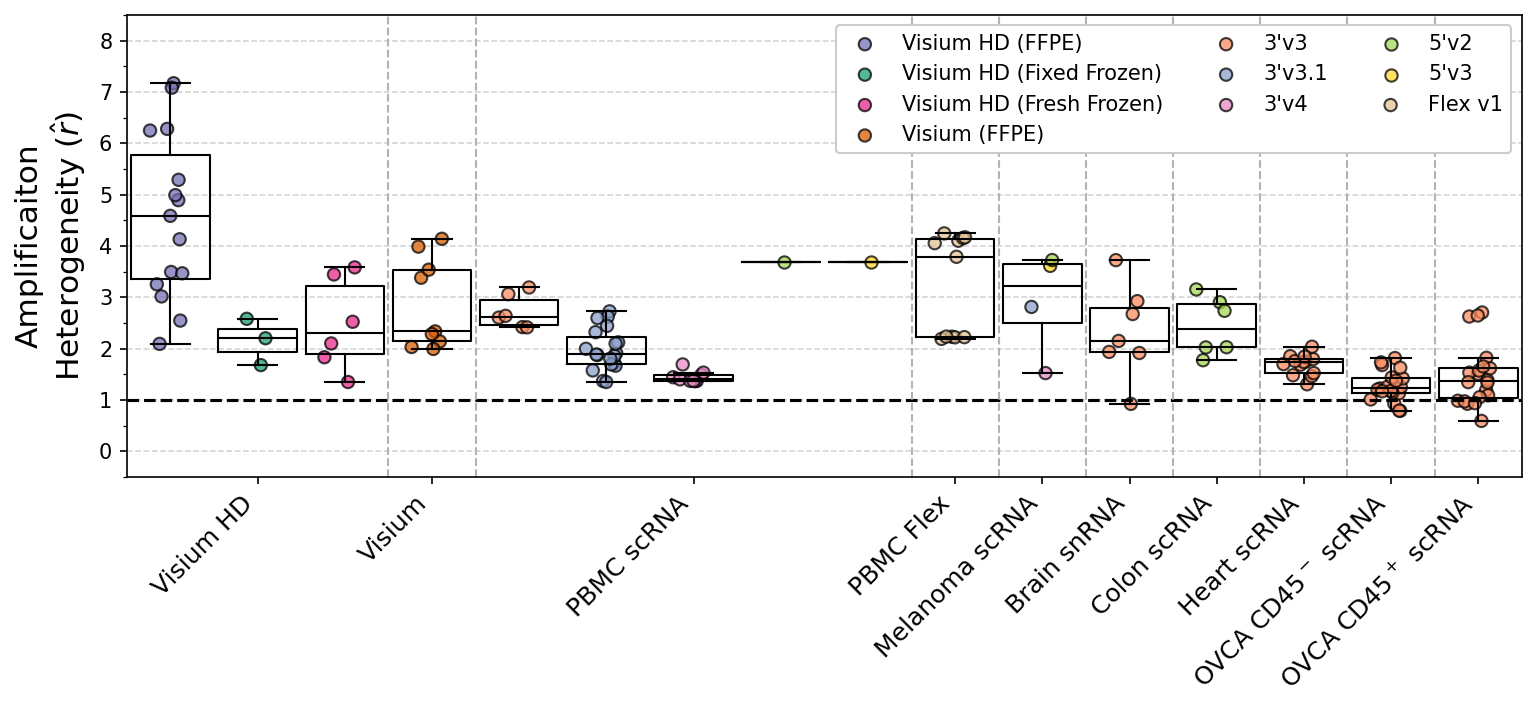

In [6]:
fig, ax = pl.figax(1, 1, w=12, h=4)
idx = 0
gaps = [2, 3, 10, 14]
mids = []
st = 0
seen = set()
mel_seen = False
lg = None
gstart = 0
for i, r in enumerate(adf.itertuples()):
    #print(i, r.group, r.subgroup, r.title) 

    if r.group == 'Melanoma':
        if mel_seen:
            continue
        mel_seen = True
        d = cdf[(cdf['group'] == r.group)]        
    else:
        d = cdf[(cdf['group'] == r.group) & (cdf['subgroup'] == r.subgroup)]
    
    lab = r.title
    print(r.group, r.subgroup, d['ztnb_rhat'].min(), d['ztnb_rhat'].max())
    if 'visium' not in r.group and 'visium_hd' not in r.group:
        if r.subgroup in seen:
            lab = '_'
        else:
            lab = r.subgroup_title
            seen.add(r.subgroup)
    pl.jitter_box(ax, idx, d['ztnb_rhat'], c=d.color, s=35, edgecolor='k', lw=1, alpha=0.75, label=lab, bwidth=0.9)
    if lg is not None and lg != r.group:
        ax.axvline(idx - 0.5, ls='--', color='0.7', lw=1)
        mids.append(gstart + (idx - gstart) / 2 - 0.5)
        gstart = idx
    idx += 1

    lg = r.group

mids.append(gstart + (idx - gstart) / 2 - 0.5)

ax.set_xticks(mids)
ax.set_xlim(-0.5, idx - 0.5)
ax.set_xticklabels(['Visium HD', 'Visium', 'PBMC scRNA', 'PBMC Flex', 'Melanoma scRNA', 'Brain snRNA', 
                    'Colon scRNA', 'Heart scRNA', 'OVCA CD45$^-$ scRNA', 'OVCA CD45$^+$ scRNA',
                    ], fontsize=12, rotation=45, ha='right')


ax.set_ylabel('Amplificaiton\nHeterogeneity ($\\hat{r}$)', fontsize=15, labelpad=5)
#ax.set_xlim(-1, idx + 0.75)
ax.set_ylim(0.5, 8.5)
ax.set_yticks(np.arange(0, 9))
ax.set_yticks(np.arange(-0.5, 9, 0.5), minor=True)
ax.axhline(1.0, ls='--', color='black', zorder=1)

ax.grid(axis='y', color='lightgray', ls='--', lw=0.75)
ax.set_axisbelow(True)


ax.legend(ncol=3, framealpha=1, loc='upper right')
fig.savefig('../Figures/Figure 2C rhat.svg', bbox_inches='tight')